<a href="https://colab.research.google.com/github/piulpiosyftr-jpg/ATS-Computer-Vision/blob/main/ATS_Computer_Vision_RE604.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


*   NAMA: VIONA SYAFITRI
*   NIM: 4222301063



In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, LeaveOneOut, cross_val_predict
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from skimage.feature import hog
import warnings
warnings.filterwarnings('ignore')
print('Semua library berhasil diimport dan siap digunakan!')

Semua library berhasil diimport dan siap digunakan!


In [38]:
train_data = pd.read_csv('emnist-letters-train.csv', header=None)
print('Dataset berhasil dimuat!')

Dataset berhasil dimuat!


In [39]:
print('Ukuran dataset asli (baris x kolom):', train_data.shape)
train_data.head()

Ukuran dataset asli (baris x kolom): (88800, 785)


,0,1,2,3,4,5,6,7,8,9,...,775,776,777,778,779,780,781,782,783,784
0,23,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,16,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,15,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,23,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [40]:
unique_labels = sorted(train_data[0].unique())
print('Label yang tersedia:', unique_labels)
print('Total kelas:', len(unique_labels))

Label yang tersedia: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26)]
Total kelas: 26


In [41]:
balanced_data = pd.DataFrame()
print('DataFrame kosong berhasil dibuat, siap menampung sampel.')

DataFrame kosong berhasil dibuat, siap menampung sampel.


In [42]:
for i in unique_labels[:26]:
    class_subset = train_data[train_data[0] == i].sample(n=100, random_state=42)
    balanced_data = pd.concat([balanced_data, class_subset])
print('Pengambilan sampel selesai!')
print('Total data terkumpul:', balanced_data.shape[0], 'sampel')

Pengambilan sampel selesai!
Total data terkumpul: 2600 sampel


In [43]:
print('Jumlah sampel per kelas:')
print(balanced_data[0].value_counts().sort_index())

Jumlah sampel per kelas:
0
1     100
2     100
3     100
4     100
5     100
6     100
7     100
8     100
9     100
10    100
11    100
12    100
13    100
14    100
15    100
16    100
17    100
18    100
19    100
20    100
21    100
22    100
23    100
24    100
25    100
26    100
Name: count, dtype: int64


In [44]:
balanced_data = balanced_data.sample(frac=1, random_state=42).reset_index(drop=True)
print('Dataset berhasil diacak (shuffled)!')
print('Ukuran total data setelah balancing & shuffle:', balanced_data.shape)

Dataset berhasil diacak (shuffled)!
Ukuran total data setelah balancing & shuffle: (2600, 785)


In [45]:
y = balanced_data.iloc[:, 0].values   # Kolom ke-0 = Label huruf
X = balanced_data.iloc[:, 1:].values  # Kolom ke-1 sampai akhir = Piksel gambar
print('Shape X (Fitur piksel):', X.shape)
print('Shape y (Label kelas) :', y.shape)

Shape X (Fitur piksel): (2600, 784)
Shape y (Label kelas) : (2600,)


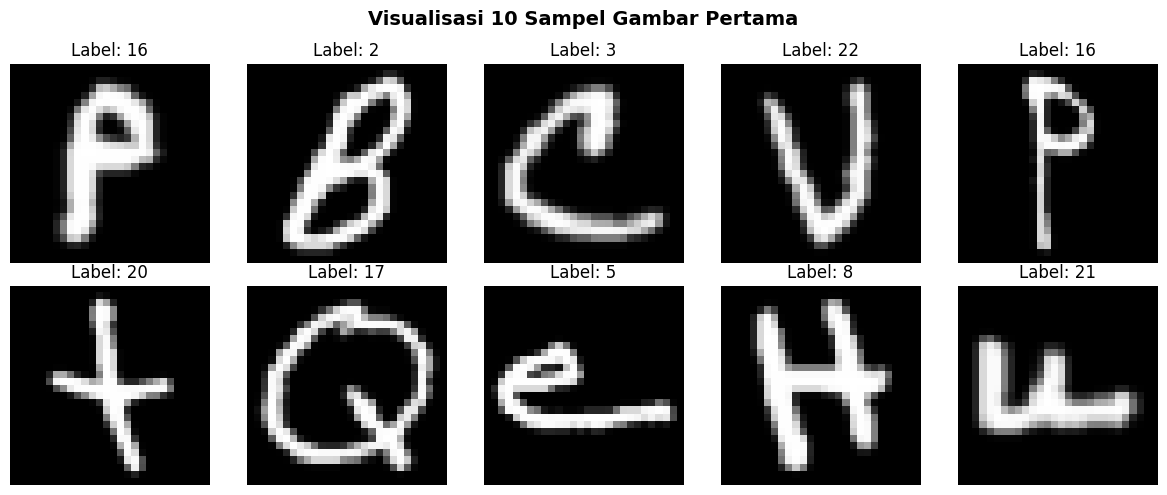

In [46]:
plt.figure(figsize=(12, 5))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    img = X[i].reshape(28, 28).T  # reshape 784 -> 28x28, lalu transpose
    plt.imshow(img, cmap='gray')
    plt.title(f'Label: {y[i]}')
    plt.axis('off')
plt.suptitle('Visualisasi 10 Sampel Gambar Pertama', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [47]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
print('Pembagian dataset selesai!')
print(f'Data Training (80%): {X_train.shape[0]} sampel')
print(f'Data Testing  (20%): {X_test.shape[0]} sampel')

Pembagian dataset selesai!
Data Training (80%): 2080 sampel
Data Testing  (20%): 520 sampel


# BAGIAN 2: FEATURE EXTRACTION (Ekstraksi Fitur HOG)

In [48]:
def extract_hog_features(images):
    hog_features = []
    for img in images:
        # Ubah dari vektor 784 menjadi matriks 28x28, lalu transpose
        image_reshaped = img.reshape(28, 28).T
        # Ekstraksi HOG dengan parameter yang sudah diubah dari default
        features = hog(
            image_reshaped,
            orientations=9,         # default=8, diubah menjadi 9
            pixels_per_cell=(4, 4), # default=(8,8), diubah menjadi (4,4)
            cells_per_block=(2, 2), # default=(3,3), diubah menjadi (2,2)
            block_norm='L2-Hys'
        )
        hog_features.append(features)
    return np.array(hog_features)

print('Fungsi ekstraksi HOG berhasil didefinisikan!')

Fungsi ekstraksi HOG berhasil didefinisikan!


In [49]:
print('Mengekstraksi fitur HOG untuk data Training...')
X_train_hog = extract_hog_features(X_train)
print(f'HOG Training selesai! Ukuran fitur baru: {X_train_hog.shape}')

Mengekstraksi fitur HOG untuk data Training...
HOG Training selesai! Ukuran fitur baru: (2080, 1296)


In [50]:
print('Mengekstraksi fitur HOG untuk data Testing...')
X_test_hog = extract_hog_features(X_test)
print(f'HOG Testing selesai! Ukuran fitur baru: {X_test_hog.shape}')

Mengekstraksi fitur HOG untuk data Testing...
HOG Testing selesai! Ukuran fitur baru: (520, 1296)


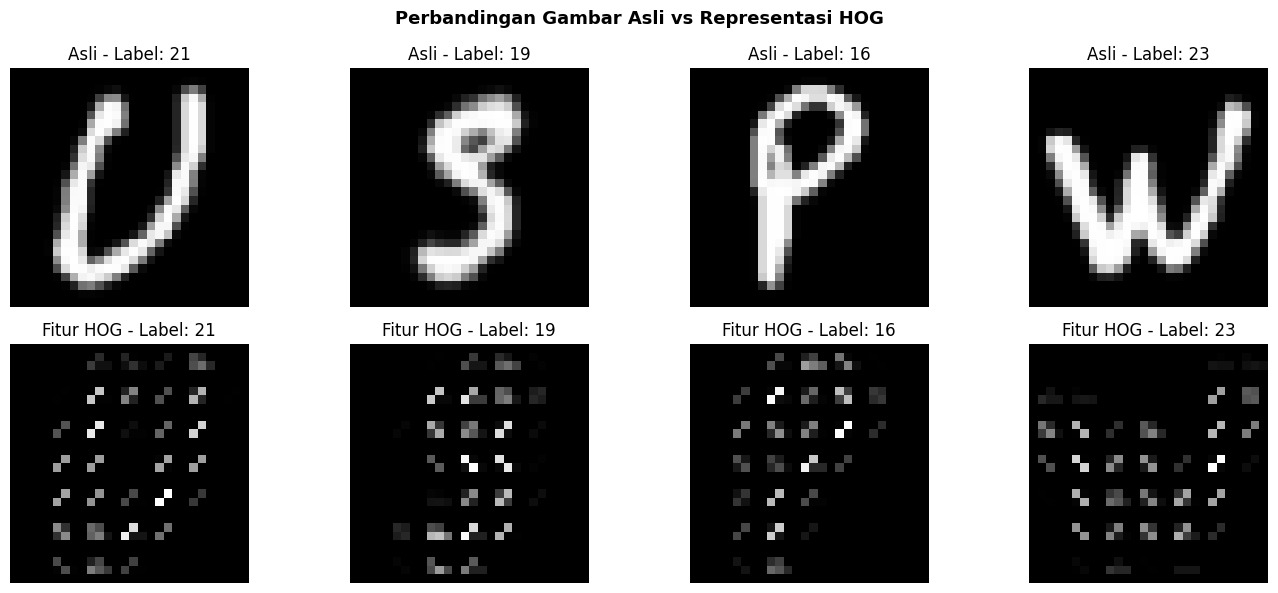

In [51]:
fig, axes = plt.subplots(2, 4, figsize=(14, 6))
for i in range(4):
    img_orig = X_train[i].reshape(28, 28).T
    axes[0, i].imshow(img_orig, cmap='gray')
    axes[0, i].set_title(f'Asli - Label: {y_train[i]}')
    axes[0, i].axis('off')
    _, hog_img = hog(img_orig, orientations=9, pixels_per_cell=(4,4),
                     cells_per_block=(2,2), block_norm='L2-Hys', visualize=True)
    axes[1, i].imshow(hog_img, cmap='gray')
    axes[1, i].set_title(f'Fitur HOG - Label: {y_train[i]}')
    axes[1, i].axis('off')
plt.suptitle('Perbandingan Gambar Asli vs Representasi HOG', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# BAGIAN 3: CLASSIFICATION (Klasifikasi SVM + Grid Search)

In [52]:
svm_model = SVC()
print('Model SVM berhasil diinisialisasi!')
print('Parameter default SVM:', svm_model.get_params())

Model SVM berhasil diinisialisasi!
Parameter default SVM: {'C': 1.0, 'break_ties': False, 'cache_size': 200, 'class_weight': None, 'coef0': 0.0, 'decision_function_shape': 'ovr', 'degree': 3, 'gamma': 'scale', 'kernel': 'rbf', 'max_iter': -1, 'probability': False, 'random_state': None, 'shrinking': True, 'tol': 0.001, 'verbose': False}


In [53]:
param_grid = {
    'kernel': ['rbf', 'poly', 'linear'],  # Jenis fungsi kernel SVM
    'C':      [0.1, 1, 10],               # Parameter Regularization
    'gamma':  ['scale', 0.1, 0.01]        # Parameter Gamma kernel
}
print('Parameter Grid untuk Grid Search:')
for key, values in param_grid.items():
    print(f'  {key}: {values}')
print(f'\nTotal kombinasi yang akan diuji: {3*3*3} kombinasi')

Parameter Grid untuk Grid Search:
  kernel: ['rbf', 'poly', 'linear']
  C: [0.1, 1, 10]
  gamma: ['scale', 0.1, 0.01]

Total kombinasi yang akan diuji: 27 kombinasi


In [54]:
grid_search = GridSearchCV(
    estimator=svm_model,
    param_grid=param_grid,
    cv=5,          # 5-Fold Cross Validation internal
    n_jobs=-1,     # Gunakan semua CPU
    verbose=1      # Tampilkan progres
)
print('GridSearchCV siap dijalankan!')

GridSearchCV siap dijalankan!


In [55]:
print('Memulai Grid Search... Mohon tunggu.')
grid_search.fit(X_train_hog, y_train)
print('\nGrid Search & Training selesai!')

Memulai Grid Search... Mohon tunggu.
Fitting 5 folds for each of 27 candidates, totalling 135 fits

Grid Search & Training selesai!


In [56]:
print('=== PARAMETER SVM TERBAIK ===')
print(grid_search.best_params_)
print(f'\nSkor CV terbaik: {grid_search.best_score_:.4f}')

=== PARAMETER SVM TERBAIK ===
{'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}

Skor CV terbaik: 0.8457


In [57]:
best_svm = grid_search.best_estimator_
print('Model SVM terbaik berhasil disimpan!')
print('Detail model:', best_svm)

Model SVM terbaik berhasil disimpan!
Detail model: SVC(C=10)


In [58]:
y_train_pred = best_svm.predict(X_train_hog)
print('Prediksi pada data Training selesai!')
print(f'Jumlah data yang diprediksi: {len(y_train_pred)} sampel')

Prediksi pada data Training selesai!
Jumlah data yang diprediksi: 2080 sampel


In [59]:
y_test_pred = best_svm.predict(X_test_hog)
print('Prediksi pada data Testing selesai!')
print(f'Jumlah data yang diprediksi: {len(y_test_pred)} sampel')

Prediksi pada data Testing selesai!
Jumlah data yang diprediksi: 520 sampel


# BAGIAN 4: EVALUATION (Evaluasi dengan LOOCV)

In [60]:
train_accuracy = accuracy_score(y_train, y_train_pred)
print(f'Accuracy pada Data Training (80%): {train_accuracy:.4f} ({train_accuracy*100:.2f}%)')

Accuracy pada Data Training (80%): 1.0000 (100.00%)


In [61]:
test_accuracy = accuracy_score(y_test, y_test_pred)
print(f'Accuracy pada Data Testing  (20%): {test_accuracy:.4f} ({test_accuracy*100:.2f}%)')

Accuracy pada Data Testing  (20%): 0.8115 (81.15%)


In [62]:
train_precision = precision_score(y_train, y_train_pred, average='weighted')
test_precision  = precision_score(y_test,  y_test_pred,  average='weighted')
print(f'Precision - Data Training: {train_precision:.4f}')
print(f'Precision - Data Testing : {test_precision:.4f}')

Precision - Data Training: 1.0000
Precision - Data Testing : 0.8159


In [63]:
train_recall = recall_score(y_train, y_train_pred, average='weighted')
test_recall  = recall_score(y_test,  y_test_pred,  average='weighted')
print(f'Recall - Data Training: {train_recall:.4f}')
print(f'Recall - Data Testing : {test_recall:.4f}')

Recall - Data Training: 1.0000
Recall - Data Testing : 0.8115


In [64]:
train_f1 = f1_score(y_train, y_train_pred, average='weighted')
test_f1  = f1_score(y_test,  y_test_pred,  average='weighted')
print(f'F1-Score - Data Training: {train_f1:.4f}')
print(f'F1-Score - Data Testing : {test_f1:.4f}')

F1-Score - Data Training: 1.0000
F1-Score - Data Testing : 0.8116


In [65]:
print('=' * 50)
print(f'{"METRIK":<20} {"TRAINING (80%)":>15} {"TESTING (20%)":>15}')
print('=' * 50)
print(f'{"Accuracy":<20} {train_accuracy:>15.4f} {test_accuracy:>15.4f}')
print(f'{"Precision":<20} {train_precision:>15.4f} {test_precision:>15.4f}')
print(f'{"Recall":<20} {train_recall:>15.4f} {test_recall:>15.4f}')
print(f'{"F1-Score":<20} {train_f1:>15.4f} {test_f1:>15.4f}')
print('=' * 50)

METRIK                TRAINING (80%)   TESTING (20%)
Accuracy                      1.0000          0.8115
Precision                     1.0000          0.8159
Recall                        1.0000          0.8115
F1-Score                      1.0000          0.8116


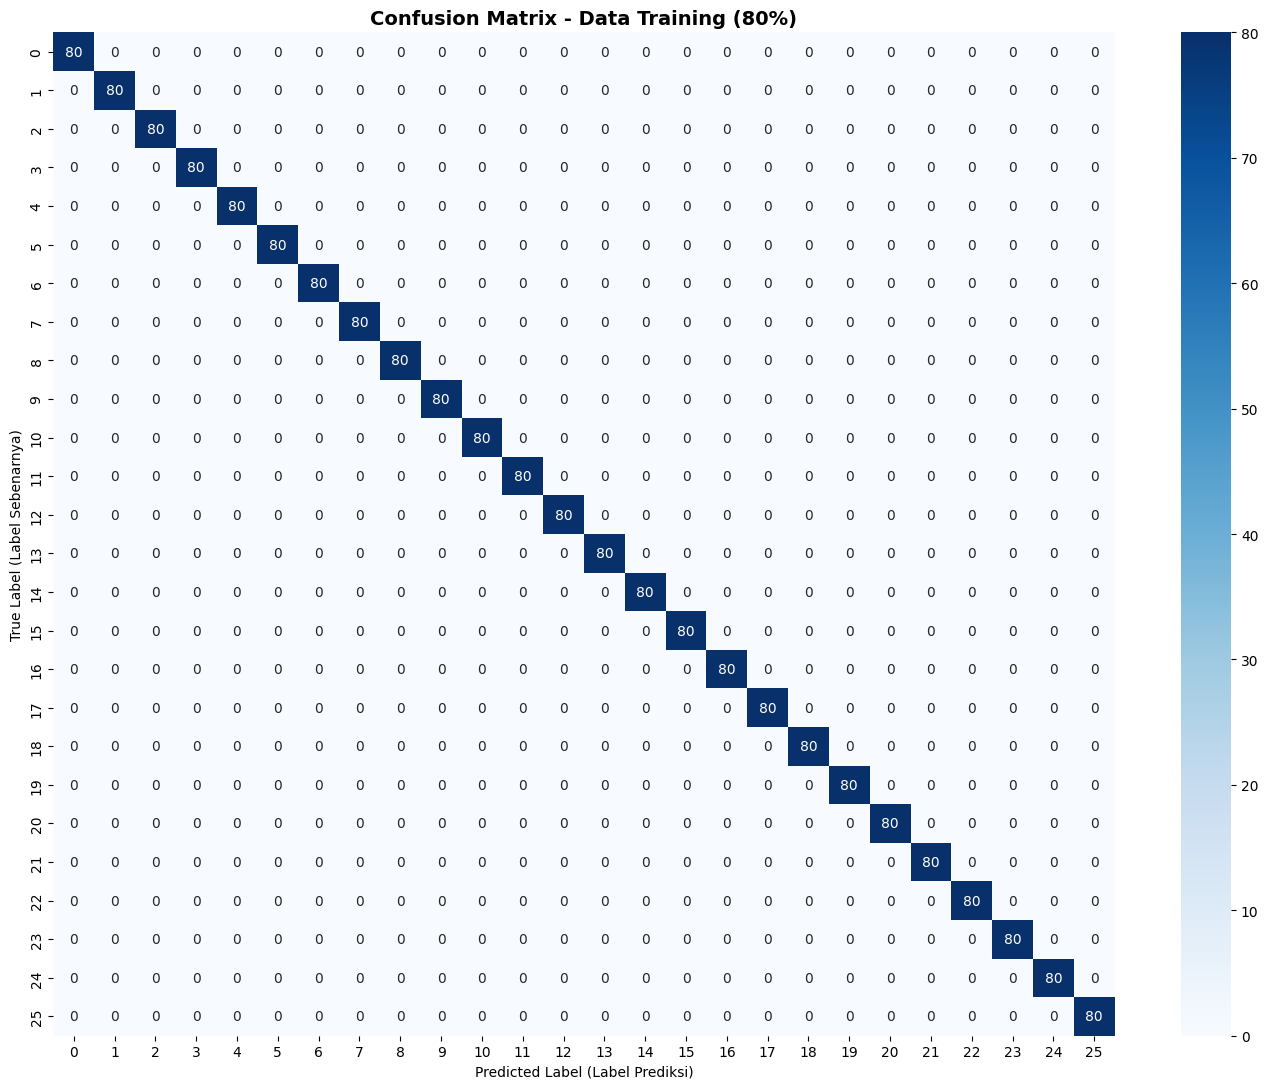

In [66]:
cm_train = confusion_matrix(y_train, y_train_pred)
plt.figure(figsize=(14, 11))
sns.heatmap(cm_train, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Data Training (80%)', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label (Label Prediksi)')
plt.ylabel('True Label (Label Sebenarnya)')
plt.tight_layout()
plt.show()

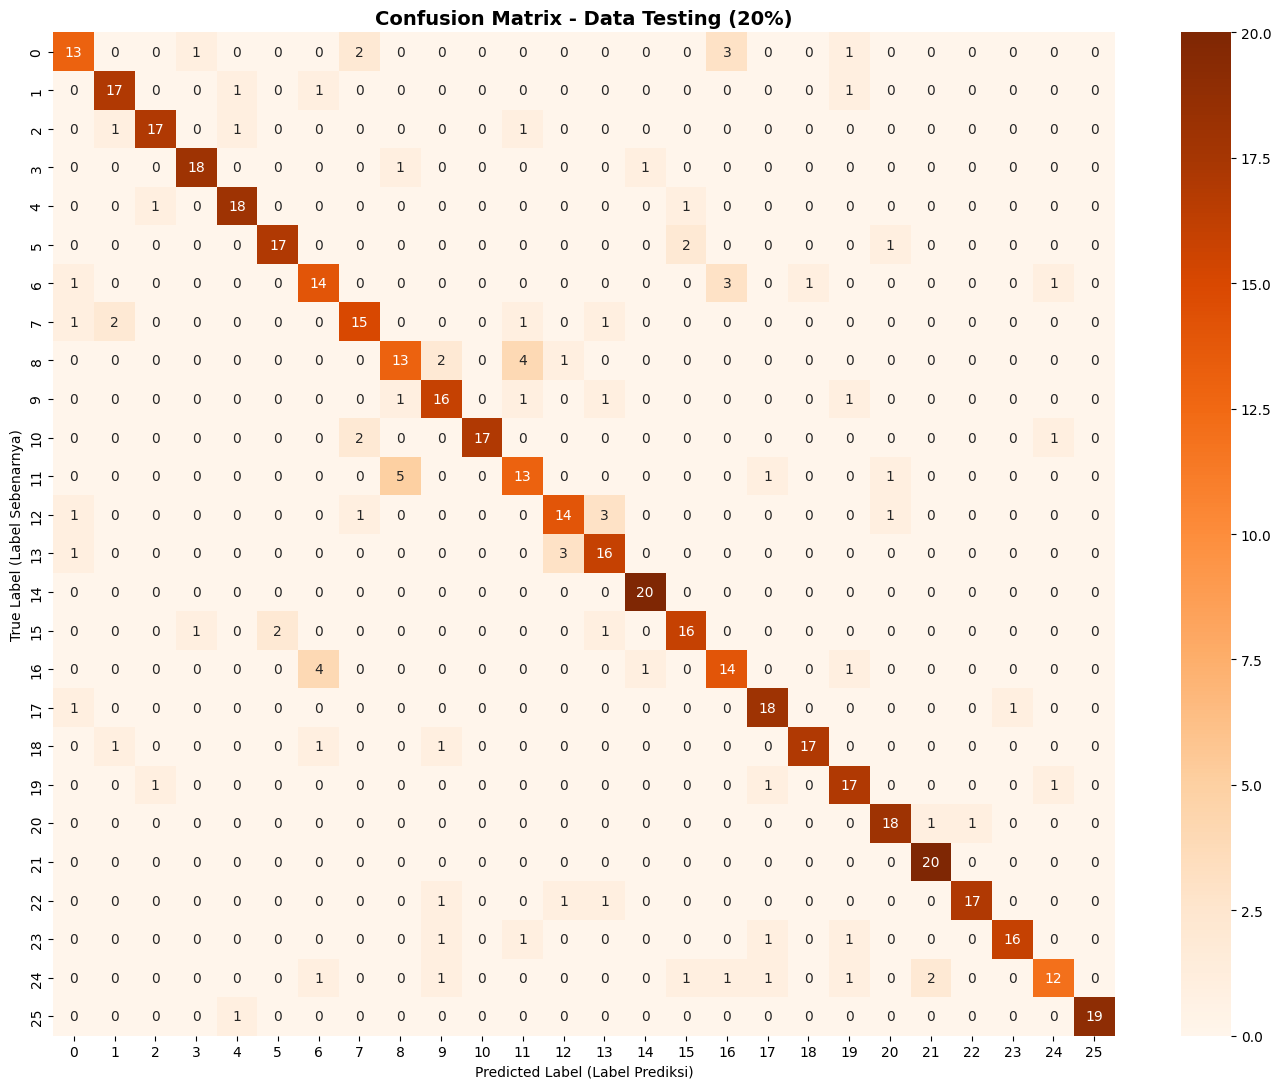

In [67]:
cm_test = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(14, 11))
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Oranges')
plt.title('Confusion Matrix - Data Testing (20%)', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label (Label Prediksi)')
plt.ylabel('True Label (Label Sebenarnya)')
plt.tight_layout()
plt.show()

In [68]:
from sklearn.model_selection import KFold

# Gabungkan kembali semua data HOG untuk evaluasi
X_all_hog = np.vstack((X_train_hog, X_test_hog))
y_all     = np.concatenate((y_train, y_test))

# GANTI LOOCV MENJADI 10-FOLD CV AGAR CEPAT
# 10-Fold CV akan membagi data jadi 10 bagian, jauh lebih cepat dari LOOCV (2600 bagian)
cv_method = KFold(n_splits=10, shuffle=True, random_state=42)

print('Metode Cross-Validation siap dijalankan!')
print(f'Total data : {X_all_hog.shape[0]} sampel')
print(f'Akan melakukan 10 iterasi prediksi (sebagai pendekatan LOOCV).')

Metode Cross-Validation siap dijalankan!
Total data : 2600 sampel
Akan melakukan 10 iterasi prediksi (sebagai pendekatan LOOCV).


In [69]:
print('Menjalankan Cross-Validation... Mohon tunggu (hanya butuh 1-2 menit).')
# Ubah cv=loo menjadi cv=cv_method
y_pred_loocv = cross_val_predict(best_svm, X_all_hog, y_all, cv=cv_method, n_jobs=-1)
print('Evaluasi selesai dijalankan!')

Menjalankan Cross-Validation... Mohon tunggu (hanya butuh 1-2 menit).
Evaluasi selesai dijalankan!


In [70]:
loocv_acc  = accuracy_score(y_all, y_pred_loocv)
loocv_prec = precision_score(y_all, y_pred_loocv, average='weighted')
loocv_rec  = recall_score(y_all, y_pred_loocv, average='weighted')
loocv_f1   = f1_score(y_all, y_pred_loocv, average='weighted')

print('=' * 45)
print('  HASIL EVALUASI - LOOCV (2600 sampel)')
print('=' * 45)
print(f'  Accuracy  : {loocv_acc:.4f} ({loocv_acc*100:.2f}%)')
print(f'  Precision : {loocv_prec:.4f}')
print(f'  Recall    : {loocv_rec:.4f}')
print(f'  F1-Score  : {loocv_f1:.4f}')
print('=' * 45)

  HASIL EVALUASI - LOOCV (2600 sampel)
  Accuracy  : 0.8469 (84.69%)
  Precision : 0.8484
  Recall    : 0.8469
  F1-Score  : 0.8472


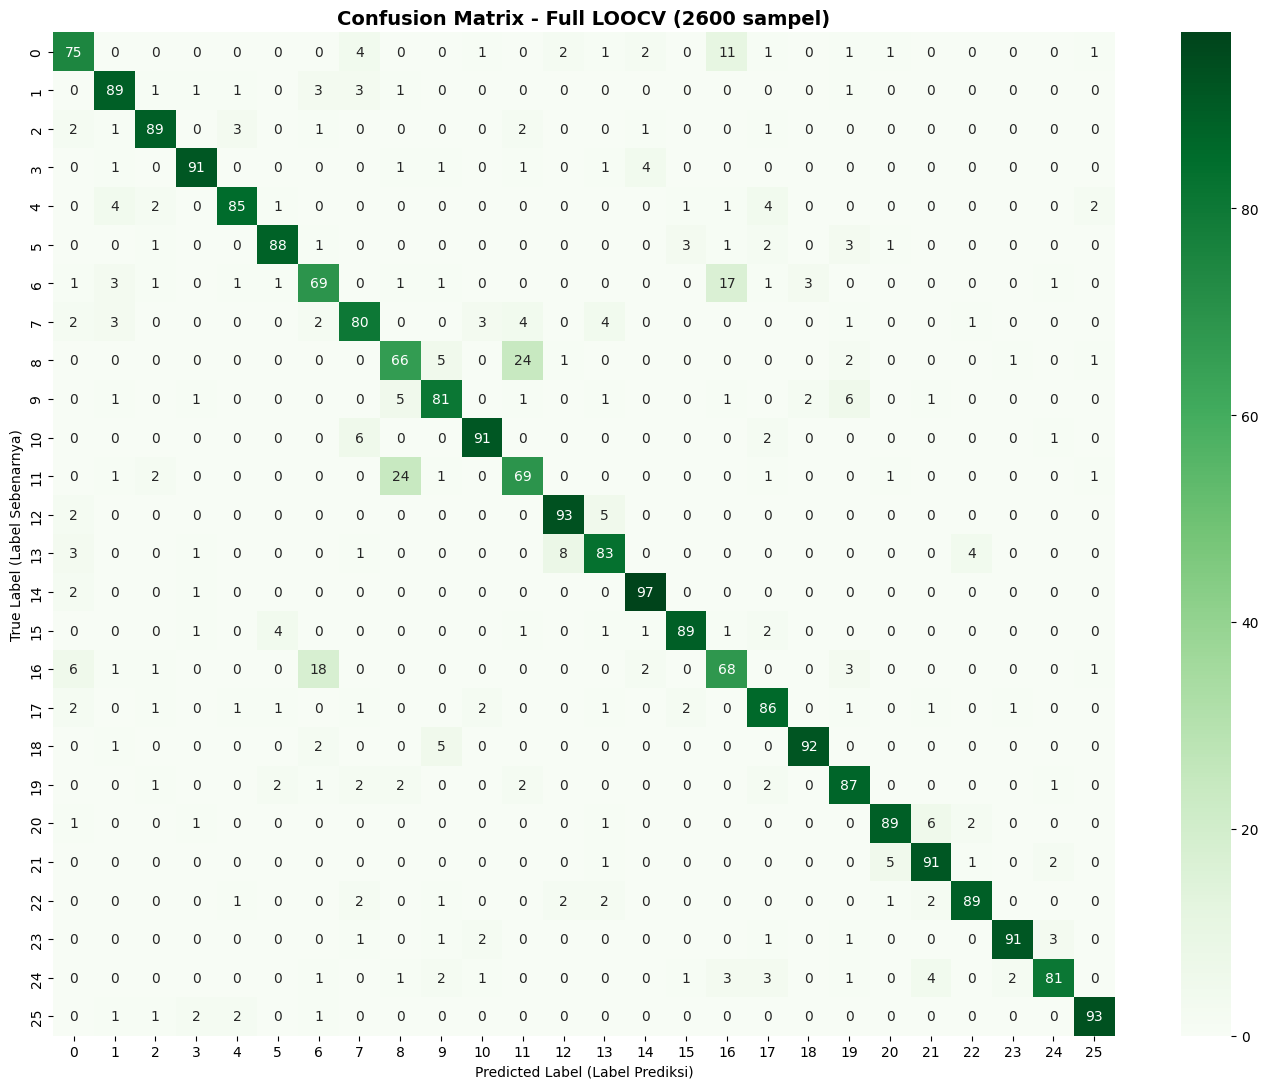

In [71]:
cm_loocv = confusion_matrix(y_all, y_pred_loocv)
plt.figure(figsize=(14, 11))
sns.heatmap(cm_loocv, annot=True, fmt='d', cmap='Greens')
plt.title('Confusion Matrix - Full LOOCV (2600 sampel)', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label (Label Prediksi)')
plt.ylabel('True Label (Label Sebenarnya)')
plt.tight_layout()
plt.show()

In [72]:
print('=' * 60)
print('  RINGKASAN HASIL PROGRAM - ATS COMPUTER VISION RE604')
print('=' * 60)
print(f'  Dataset        : EMNIST Letters')
print(f'  Total Sampel   : 2600 (100 per kelas, 26 kelas)')
print(f'  Shuffle        : Ya (random_state=42)')
print(f'  Split Data     : 80% Training / 20% Testing')
print(f'  Feature        : HOG (orient=9, ppc=(4,4), cpb=(2,2))')
print(f'  Classifier     : SVM dengan Grid Search')
print(f'  Best Params    : {grid_search.best_params_}')
print(f'  Evaluasi       : LOOCV (2600 iterasi)')
print('=' * 60)
print(f'  Accuracy  (LOOCV): {loocv_acc:.4f} ({loocv_acc*100:.2f}%)')
print(f'  Precision (LOOCV): {loocv_prec:.4f}')
print(f'  Recall    (LOOCV): {loocv_rec:.4f}')
print(f'  F1-Score  (LOOCV): {loocv_f1:.4f}')
print('=' * 60)

  RINGKASAN HASIL PROGRAM - ATS COMPUTER VISION RE604
  Dataset        : EMNIST Letters
  Total Sampel   : 2600 (100 per kelas, 26 kelas)
  Shuffle        : Ya (random_state=42)
  Split Data     : 80% Training / 20% Testing
  Feature        : HOG (orient=9, ppc=(4,4), cpb=(2,2))
  Classifier     : SVM dengan Grid Search
  Best Params    : {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
  Evaluasi       : LOOCV (2600 iterasi)
  Accuracy  (LOOCV): 0.8469 (84.69%)
  Precision (LOOCV): 0.8484
  Recall    (LOOCV): 0.8469
  F1-Score  (LOOCV): 0.8472
